In [ ]:
import torch
import numpy as np
from torch.utils.data import Dataset

class RegressionDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

class ClassificationDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

def make_regression_data(n=100, noise=0.1, source='random'):
    if source == 'random':
        X = torch.rand(n, 1)
        w, b = 2.0, -1.0
        y = w * X + b + noise * torch.randn(n, 1)
        return X, y
    elif source == 'diabetes':
        from sklearn.datasets import load_diabetes
        data = load_diabetes()
        X = torch.tensor(data['data'], dtype=torch.float32)
        y = torch.tensor(data['target'], dtype=torch.float32).unsqueeze(1)
        return X, y
    else:
        raise ValueError('Unknown source')

def make_classification_data(n=100, source='random'):
    if source == 'random':
        X = torch.rand(n, 2)
        w = torch.tensor([2.0, -3.0])
        b = 0.5
        logits = X @ w + b
        y = (logits > 0).float().unsqueeze(1)
        return X, y
    elif source == 'breast_cancer':
        from sklearn.datasets import load_breast_cancer
        data = load_breast_cancer()
        X = torch.tensor(data['data'], dtype=torch.float32)
        y = torch.tensor(data['target'], dtype=torch.float32).unsqueeze(1)
        return X, y
    else:
        raise ValueError('Unknown source')

def mse(y_pred, y_true):
    return ((y_pred - y_true) ** 2).mean().item()

def accuracy(y_pred, y_true):
    y_pred_bin = (y_pred > 0.5).float()
    return (y_pred_bin == y_true).float().mean().item()

def log_epoch(epoch, loss, **metrics):
    msg = f"Epoch {epoch}: loss={loss:.4f}"
    for k, v in metrics.items():
        msg += f", {k}={v:.4f}"
    print(msg)

In [23]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

class EarlyStopping:
    """
    Класс для реализации ранней остановки (Early Stopping).
    Останавливает обучение, если метрика на валидации не улучшается.
    """
    def __init__(self, patience: int = 5, min_delta: float = 0.0):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = None
        self.early_stop = False

    def __call__(self, val_loss: float):
        if self.best_loss is None:
            self.best_loss = val_loss
        elif val_loss > self.best_loss - self.min_delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_loss = val_loss
            self.counter = 0


class LinearRegression(nn.Module):
    def __init__(self, in_features):
        super().__init__()
        self.linear = nn.Linear(in_features, 1)

    def forward(self, x):
        return self.linear(x)


if __name__ == '__main__':
    X, y = make_regression_data(n=250)

    # Разбиваем данные на Train и Val
    X_train, y_train = X[:200], y[:200]
    X_val, y_val = X[200:], y[200:]

    # Создаём датасет и даталоадер только для обучающей выборки
    dataset = RegressionDataset(X_train, y_train)
    dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

    print(f'Размер обучающего датасета: {len(dataset)}')
    print(f'Размер валидационного датасета: {len(X_val)}')
    print(f'Количество батчей: {len(dataloader)}\n')


    model = LinearRegression(in_features=1)
    criterion = nn.MSELoss()
    optimizer = optim.SGD(model.parameters(), lr=0.1)

    l1_lambda = 0.01
    l2_lambda = 0.01
    early_stopping = EarlyStopping(patience=5, min_delta=0.001)


    epochs = 100
    for epoch in range(1, epochs + 1):
        model.train()
        total_loss = 0

        for i, (batch_X, batch_y) in enumerate(dataloader):
            optimizer.zero_grad()
            y_pred = model(batch_X)

            base_loss = criterion(y_pred, batch_y)

            # Вычисление штрафов L1 и L2
            l1_penalty = 0.0
            l2_penalty = 0.0
            for param in model.parameters():
                l1_penalty += torch.norm(param, p=1)
                l2_penalty += torch.norm(param, p=2) ** 2

            # Добавляем штрафы к итоговой функции потерь
            loss = base_loss + (l1_lambda * l1_penalty) + (l2_lambda * l2_penalty)

            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        avg_train_loss = total_loss / len(dataloader)


        model.eval() # Переводим модель в режим оценки
        with torch.no_grad(): # Отключаем слежку за градиентами
            val_pred = model(X_val)
            val_loss = criterion(val_pred, y_val).item()

        if epoch % 10 == 0:
            log_epoch(epoch, avg_train_loss, val_loss=val_loss)

        early_stopping(val_loss)
        if early_stopping.early_stop:
            print(f'\n[!] Сработал Early Stopping на эпохе {epoch}. Ошибка на валидации перестала падать.')
            break

    os.makedirs('homework/models', exist_ok=True)
    # Сохраняем модифицированную модель
    torch.save(model.state_dict(), 'homework/models/linreg_torch_modified.pth')
    print("\nМодель успешно сохранена в 'homework/models/linreg_torch_modified.pth'")

Размер обучающего датасета: 200
Размер валидационного датасета: 50
Количество батчей: 7

Epoch 10: loss=0.0920, val_loss=0.0658
Epoch 20: loss=0.0798, val_loss=0.0333
Epoch 30: loss=0.0765, val_loss=0.0267

[!] Сработал Early Stopping на эпохе 30. Ошибка на валидации перестала падать.

Модель успешно сохранена в 'homework/models/linreg_torch_modified.pth'


Эпоха 10: Train Loss = 0.7839
Эпоха 20: Train Loss = 0.7818
Эпоха 30: Train Loss = 0.7952
Эпоха 40: Train Loss = 0.7800
Эпоха 50: Train Loss = 0.7718

--- Итоговые метрики на валидации ---
Precision (Точность): 0.7205
Recall (Полнота):     0.7160
F1-score (Баланс):    0.6926
ROC-AUC:              0.8508


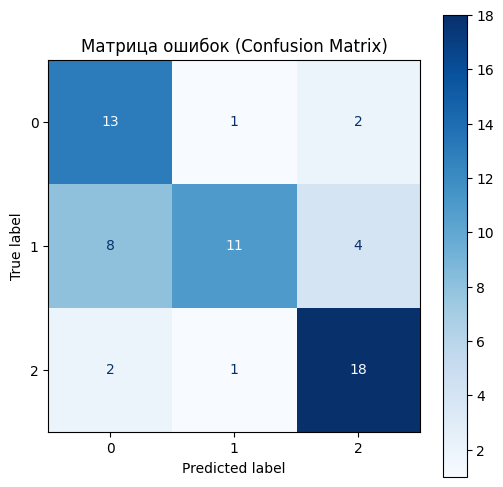

In [20]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.metrics import precision_recall_fscore_support, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay

class MulticlassDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

class MulticlassLogisticRegression(nn.Module):
    def __init__(self, in_features, num_classes):
        super().__init__()
        self.linear = nn.Linear(in_features, num_classes)

    def forward(self, x):
        return self.linear(x)

def run_multiclass_experiment():

    # Генерируем датасет на 3 класса
    X, y = make_classification(
        n_samples=300,
        n_features=4,
        n_informative=3,
        n_redundant=0,
        n_classes=3,
        random_state=42
    )

    # Разбиваем на train, val
    X_train, y_train = X[:240], y[:240]
    X_val, y_val = X[240:], y[240:]

    dataset = MulticlassDataset(X_train, y_train)
    dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

    # 4 признака на входе, 3 класса на выходе
    model = MulticlassLogisticRegression(in_features=4, num_classes=3)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.05)

    epochs = 50
    for epoch in range(1, epochs + 1):
        model.train()
        total_loss = 0
        for batch_X, batch_y in dataloader:
            optimizer.zero_grad()
            logits = model(batch_X)
            loss = criterion(logits, batch_y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        if epoch % 10 == 0:
            print(f"Эпоха {epoch}: Train Loss = {total_loss/len(dataloader):.4f}")

    # Валидация и метрики
    model.eval()
    with torch.no_grad():
        val_logits = model(torch.tensor(X_val, dtype=torch.float32))

        val_probs = torch.softmax(val_logits, dim=1)

        val_preds = torch.argmax(val_probs, dim=1)

    # Переводим тензоры в numpy для работы sklearn
    y_val_np = y_val
    val_preds_np = val_preds.numpy()
    val_probs_np = val_probs.numpy()

    # Precision, Recall, F1.
    #  считаем метрику для каждого класса отдельно, а потом берем среднее
    precision, recall, f1, _ = precision_recall_fscore_support(y_val_np, val_preds_np, average='macro', zero_division=0)

    # Для ROC-AUC многоклассовой классификации нужен параметр multi_class='ovr'
    roc_auc = roc_auc_score(y_val_np, val_probs_np, multi_class='ovr')

    print("\n--- Итоговые метрики на валидации ---")
    print(f"Precision (Точность): {precision:.4f}")
    print(f"Recall (Полнота):     {recall:.4f}")
    print(f"F1-score (Баланс):    {f1:.4f}")
    print(f"ROC-AUC:              {roc_auc:.4f}")

    cm = confusion_matrix(y_val_np, val_preds_np)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)

    # график
    fig, ax = plt.subplots(figsize=(6, 6))
    disp.plot(cmap=plt.cm.Blues, ax=ax)
    plt.title("Матрица ошибок (Confusion Matrix)")
    plt.show()

if __name__ == '__main__':
    run_multiclass_experiment()
    torch.save(model.state_dict(), 'logreg_torch_modified.pth')

In [ ]:
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import fetch_california_housing, fetch_openml
from sklearn.metrics import accuracy_score, mean_squared_error
import os


class CustomCSVDataset(Dataset):
    """
    Универсальный класс для загрузки и предобработки данных из CSV файла.
    """
    def __init__(self, csv_path: str, target_col: str, task_type: str = 'regression'):
        """
        Args:
            csv_path: Путь к файлу CSV
            target_col: Имя колонки, которую мы предсказываем
            task_type: 'regression' или 'classification'
        """
        print(f"Загрузка данных из {csv_path}...")
        df = pd.read_csv(csv_path)

        df = df.dropna()

        # Разделяем признаки
        self.y_data = df[target_col].values
        X_df = df.drop(columns=[target_col])

        cat_cols = X_df.select_dtypes(include=['object', 'category']).columns
        num_cols = X_df.select_dtypes(include=['number']).columns

        # Кодируем текстовые категории
        if len(cat_cols) > 0:
            X_df = pd.get_dummies(X_df, columns=cat_cols, drop_first=True)
            X_df = X_df.astype(float)

        # Нормализуем числовые признаки
        if len(num_cols) > 0:
            scaler = StandardScaler()
            X_df[num_cols] = scaler.fit_transform(X_df[num_cols])

        self.X = torch.tensor(X_df.values, dtype=torch.float32)

        if task_type == 'regression':
            self.y = torch.tensor(self.y_data, dtype=torch.float32).unsqueeze(1)
        elif task_type == 'classification':
            self.y = torch.tensor(self.y_data, dtype=torch.float32).unsqueeze(1)

        self.input_dim = self.X.shape[1]
        print(f"Загружено строк: {len(self.X)}. Признаков после обработки: {self.input_dim}")

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


def prepare_mock_csv_files():
    """Скачивает CSV файлы для тестов (Калифорнийские дома и Титаник)."""
    if not os.path.exists('data'):
        os.makedirs('data')

    if not os.path.exists('homework/data/regression_data.csv'):
        cali = fetch_california_housing(as_frame=True)
        cali.frame.to_csv('homework/data/regression_data.csv', index=False)

    if not os.path.exists('homework/data/classification_data.csv'):
        titanic = fetch_openml(name='titanic', version=1, as_frame=True)
        df = titanic.frame
        cols_to_keep = ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'survived']
        df = df[cols_to_keep].dropna()
        df.to_csv('homework/data/classification_data.csv', index=False)

def train_and_evaluate(model, dataloader, task_type='regression', epochs=20, lr=0.01):
    """Универсальный цикл обучения для регрессии и бинарной классификации."""
    if task_type == 'regression':
        criterion = nn.MSELoss()
    else:
        criterion = nn.BCEWithLogitsLoss()

    optimizer = optim.Adam(model.parameters(), lr=lr)

    model.train()
    for epoch in range(1, epochs + 1):
        total_loss = 0
        for batch_X, batch_y in dataloader:
            optimizer.zero_grad()
            predictions = model(batch_X)
            loss = criterion(predictions, batch_y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

    model.eval()
    with torch.no_grad():
        all_X = dataloader.dataset.X
        all_y = dataloader.dataset.y
        preds = model(all_X)

        if task_type == 'regression':
            final_loss = criterion(preds, all_y).item()
            print(f"Обучение завершено. Итоговый MSE Loss: {final_loss:.4f}\n")
        else:
            probs = torch.sigmoid(preds)
            pred_classes = (probs > 0.5).float()
            acc = accuracy_score(all_y.numpy(), pred_classes.numpy())
            print(f"Обучение завершено. Итоговая Accuracy (Точность): {acc:.4f} ({acc*100:.1f}%)\n")


#---------- 2.2 Эксперименты с датасетами --------
def run_dataset_experiments():
    prepare_mock_csv_files()

    print("\n--- Эксперимент 1: Регрессия (Цены на жилье) ---")
    reg_dataset = CustomCSVDataset(
        csv_path='homework/data/regression_data.csv',
        target_col='MedHouseVal',
        task_type='regression'
    )
    reg_dataloader = DataLoader(reg_dataset, batch_size=64, shuffle=True)

    # Модель - простая линейная регрессия
    lin_reg_model = nn.Linear(reg_dataset.input_dim, 1)
    train_and_evaluate(lin_reg_model, reg_dataloader, task_type='regression', epochs=30, lr=0.05)

    print("--- Эксперимент 2: Бинарная классификация (Выживание на Титанике) ---")
    clf_dataset = CustomCSVDataset(
        csv_path='homework/data/classification_data.csv',
        target_col='survived',
        task_type='classification'
    )
    clf_dataloader = DataLoader(clf_dataset, batch_size=32, shuffle=True)

    # Модель - логистическая регрессия
    log_reg_model = nn.Linear(clf_dataset.input_dim, 1)
    train_and_evaluate(log_reg_model, clf_dataloader, task_type='classification', epochs=30, lr=0.01)

if __name__ == '__main__':
    run_dataset_experiments()


--- Эксперимент 1: Регрессия (Цены на жилье) ---
Загрузка данных из data/regression_data.csv...
Загружено строк: 20640. Признаков после обработки: 8
Обучение завершено. Итоговый MSE Loss: 0.5412

--- Эксперимент 2: Бинарная классификация (Выживание на Титанике) ---
Загрузка данных из data/classification_data.csv...
Загружено строк: 1043. Признаков после обработки: 8
Обучение завершено. Итоговая Accuracy (Точность): 0.7948 (79.5%)



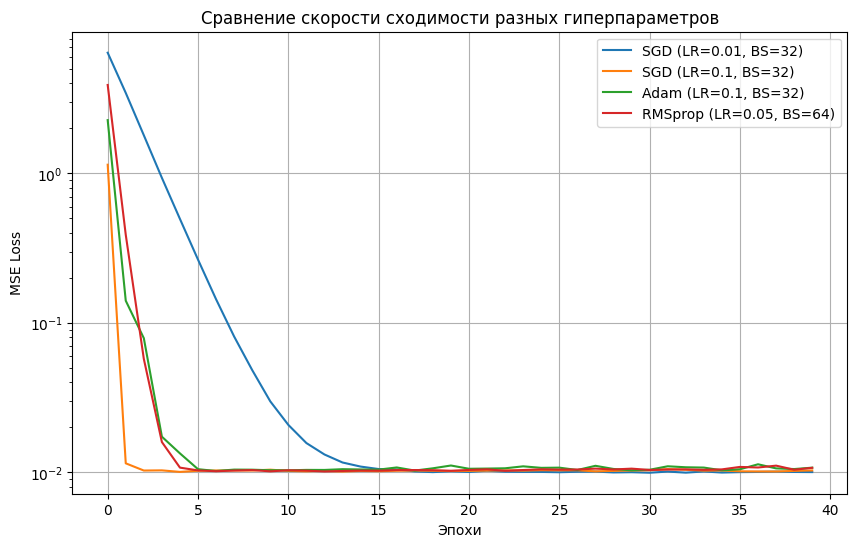

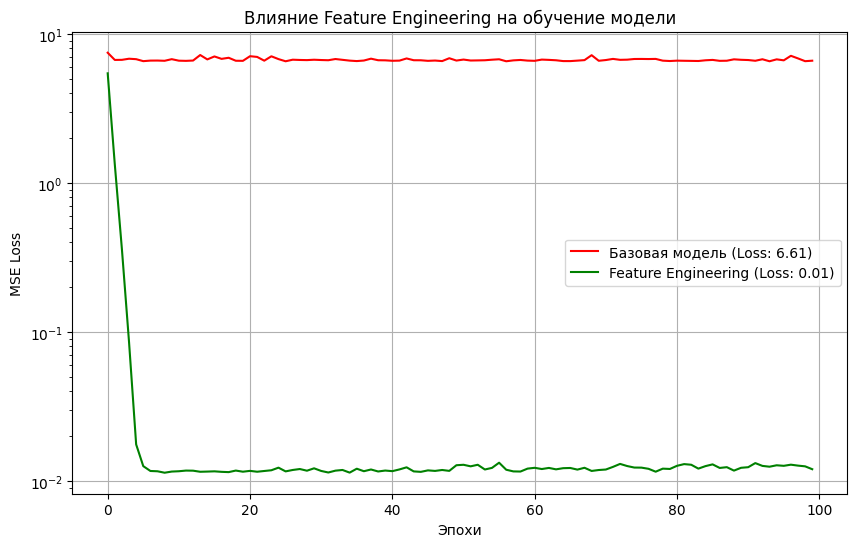

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
import logging
import numpy as np

# Настройка логирования
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s'
)
logger = logging.getLogger(__name__)

# Базовая модель и цикл обучения для экспериментов
class SimpleLinearRegression(nn.Module):
    def __init__(self, in_features):
        super().__init__()
        self.linear = nn.Linear(in_features, 1)

    def forward(self, x):
        return self.linear(x)

def train_experiment(X: torch.Tensor, y: torch.Tensor,
                    batch_size: int = 32, lr: float = 0.01,
                    optimizer_name: str = 'SGD', epochs: int = 50) -> list:
    """
    Универсальная функция для обучения модели с заданными гиперпараметрами.

    Returns:
        loss_history (list): История изменения функции потерь по эпохам.
    """
    dataset = TensorDataset(X, y)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    model = SimpleLinearRegression(in_features=X.shape[1])
    criterion = nn.MSELoss()

    # Выбор оптимизатора
    if optimizer_name == 'SGD':
        optimizer = optim.SGD(model.parameters(), lr=lr)
    elif optimizer_name == 'Adam':
        optimizer = optim.Adam(model.parameters(), lr=lr)
    elif optimizer_name == 'RMSprop':
        optimizer = optim.RMSprop(model.parameters(), lr=lr)
    else:
        raise ValueError(f"Неизвестный оптимизатор: {optimizer_name}")

    loss_history = []

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for batch_X, batch_y in dataloader:
            optimizer.zero_grad()
            pred = model(batch_X)
            loss = criterion(pred, batch_y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        avg_loss = total_loss / len(dataloader)
        loss_history.append(avg_loss)

    return loss_history

# 3.1 Исследование гиперпараметров
def run_hyperparameter_experiments():
    logger.info("Начало Эксперимента 3.1: Исследование гиперпараметров")

    # Генерим линейную зависимость
    torch.manual_seed(42)
    X = torch.randn(500, 3)
    true_w = torch.tensor([[2.0], [-1.5], [0.8]])
    y = X @ true_w + 0.5 + torch.randn(500, 1) * 0.1

    configs = [
        {'opt': 'SGD', 'lr': 0.01, 'bs': 32},
        {'opt': 'SGD', 'lr': 0.1, 'bs': 32},
        {'opt': 'Adam', 'lr': 0.1, 'bs': 32},
        {'opt': 'RMSprop', 'lr': 0.05, 'bs': 64}
    ]

    plt.figure(figsize=(10, 6))

    for conf in configs:
        logger.info(f"Обучение: Оптимизатор={conf['opt']}, LR={conf['lr']}, Batch={conf['bs']}")
        history = train_experiment(X, y, batch_size=conf['bs'], lr=conf['lr'],
                                   optimizer_name=conf['opt'], epochs=40)
        plt.plot(history, label=f"{conf['opt']} (LR={conf['lr']}, BS={conf['bs']})")

    plt.title("Сравнение скорости сходимости разных гиперпараметров")
    plt.xlabel("Эпохи")
    plt.ylabel("MSE Loss")
    plt.yscale('log') # Логарифмическая шкала
    plt.legend()
    plt.grid(True)
    plt.show()

# 3.2 Feature Engineering
def run_feature_engineering_experiments():
    logger.info("Начало Эксперимента 3.2: Feature Engineering")

    # Генерим нелинейные данные
    torch.manual_seed(42)
    X_base = torch.randn(500, 2)
    # y = x1^2 + 2*x1*x2
    y = (X_base[:, 0]**2 + 2 * X_base[:, 0] * X_base[:, 1]).unsqueeze(1) + torch.randn(500, 1) * 0.1

    # Обучаем базовую модель на исходных данных
    logger.info("Обучение базовой модели ...")
    base_history = train_experiment(X_base, y, batch_size=32, lr=0.05, optimizer_name='Adam', epochs=100)
    final_base_loss = base_history[-1]

    # Добавляем новые признаки x1^2, x2^2
    feat_sq = X_base ** 2

    # Взаимодействия: x1 * x2
    feat_interact = (X_base[:, 0] * X_base[:, 1]).unsqueeze(1)

    # Статистические: среднее и дисперсия по строке
    feat_mean = X_base.mean(dim=1, keepdim=True)
    feat_var = X_base.var(dim=1, keepdim=True)

    X_engineered = torch.cat([X_base, feat_sq, feat_interact, feat_mean, feat_var], dim=1)

    logger.info(f"Количество признаков увеличено с {X_base.shape[1]} до {X_engineered.shape[1]}")

    # Обучаем модель на расширенных данных
    logger.info("Обучение продвинутой модели (с новыми признаками)...")
    eng_history = train_experiment(X_engineered, y, batch_size=32, lr=0.05, optimizer_name='Adam', epochs=100)
    final_eng_loss = eng_history[-1]

    logger.info(f"Итоговый MSE базовой модели: {final_base_loss:.4f}")
    logger.info(f"Итоговый MSE с Feature Engineering: {final_eng_loss:.4f}")

    plt.figure(figsize=(10, 6))
    plt.plot(base_history, label=f"Базовая модель (Loss: {final_base_loss:.2f})", color='red')
    plt.plot(eng_history, label=f"Feature Engineering (Loss: {final_eng_loss:.2f})", color='green')
    plt.title("Влияние Feature Engineering на обучение модели")
    plt.xlabel("Эпохи")
    plt.ylabel("MSE Loss")
    plt.yscale('log')
    plt.legend()
    plt.grid(True)
    plt.show()

if __name__ == '__main__':
    run_hyperparameter_experiments()
    print("\n" + "="*50 + "\n")
    run_feature_engineering_experiments()